# Wahadło Oberbecka — M7

**Badanie ruchu obrotowego bryły sztywnej.**  
Trzy sub-eksperymenty:
1. Zależność $t^2$ od $h$ (odległość między bramkami)
2. Zależność $t^2$ od $d_W^2$ (pozycja ciężarków na ramionach)
3. Zależność $t^2$ od $1/m$ (masa szalki)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'figure.dpi': 150,
})

# Paleta kolorów dla 4 grup w każdym eksperymencie
COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # niebieski, pomarańczowy, zielony, czerwony

In [2]:
def format_val_unc(val, unc, n=2):
    """Formatuje wartość ± niepewność z zaokrągleniem do n cyfr znaczących niepewności."""
    if unc == 0 or np.isnan(unc) or np.isnan(val):
        return f"{val:.4g}", f"{unc:.4g}"
    d = int(np.floor(np.log10(abs(unc)))) - (n - 1)
    unc_r = round(unc, -d)
    val_r = round(val, -d)
    if d <= 0:
        fmt = f".{-d}f"
        return f"{val_r:{fmt}}", f"{unc_r:{fmt}}"
    else:
        return f"{val_r:.0f}", f"{unc_r:.0f}"


def fit_linear(x, y, yerr=None):
    """Ważona regresja liniowa y = ax + b (MNK).
    yerr: niepewności y_i; wagi w_i = 1/yerr_i².
    Bez yerr: zwykła OLS z sigma² z reszt.
    Zwraca (a, u_a, b, u_b, R2)."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)
    A = np.vstack([x, np.ones(n)]).T
    if yerr is not None:
        w = 1.0 / np.asarray(yerr, dtype=float)**2
        W = np.diag(w)
        AtWA = A.T @ W @ A
        a, b = np.linalg.solve(AtWA, A.T @ (w * y))
        cov = np.linalg.inv(AtWA)
        residuals = y - (a * x + b)
        y_wmean = np.sum(w * y) / np.sum(w)
        ss_res = np.sum(w * residuals**2)
        ss_tot = np.sum(w * (y - y_wmean)**2)
    else:
        a, b = np.linalg.lstsq(A, y, rcond=None)[0]
        residuals = y - (a * x + b)
        ss_res = np.dot(residuals, residuals)
        ss_tot = np.sum((y - y.mean())**2)
        cov = (ss_res / (n - 2)) * np.linalg.inv(A.T @ A)
    r2 = 1.0 - ss_res / ss_tot
    da = np.sqrt(cov[0, 0])
    db = np.sqrt(cov[1, 1])
    return a, da, b, db, r2

In [3]:
# Wczytaj dane
df1 = pd.read_csv('1_t2_h.csv')       # t² vs h
df2 = pd.read_csv('2_t2_dw2.csv')     # t² vs r_W
df3 = pd.read_csv('3_t2_m-1.csv')     # t² vs m
spool = pd.read_csv('spool_diameter.csv')

# Parametry szpuli
Ds   = spool['Ds'].values[0]      # mm
u_Ds = spool['u_Ds'].values[0]    # mm
r    = Ds / 2 / 1000              # m
u_r  = u_Ds / 2 / 1000           # m

# Masa obciążnika rozpędzającego — Eksp. 1
hm1  = pd.read_csv('1_hanging_mass.csv')
m1   = hm1['m'].values[0]   * 1e-3   # kg
u_m1 = hm1['u_m'].values[0] * 1e-3   # kg

# Masa obciążnika rozpędzającego — Eksp. 2
hm2  = pd.read_csv('2_hanging_mass.csv')
m2   = hm2['m'].values[0]   * 1e-3   # kg
u_m2 = hm2['u_m'].values[0] * 1e-3   # kg

# Parametry walcowych ciężarków — Eksp. 2 (sumaryczna masa obu walców)
pm   = pd.read_csv('2_pendulum_mass.csv')
M_W  = pm['m'].values[0]   * 1e-3    # kg — łączna masa 2 walców
u_MW = pm['u_m'].values[0] * 1e-3    # kg

wd   = pd.read_csv('2_weight_diameter.csv')
d_W  = wd['d'].values[0]             # mm — średnica walca
u_dW = wd['u_d'].values[0]           # mm
R_W  = d_W / 2 / 1000                # m — promień walca
u_RW = u_dW / 2 / 1000               # m

wt     = pd.read_csv('2_weight_thickness.csv')
H_W    = wt['h'].values[0]           # mm — grubość walca
u_HW   = wt['u_h'].values[0]         # mm
H_W_m  = H_W  / 1000                 # m
u_HW_m = u_HW / 1000                 # m

# Odległość bramek — Eksp. 2
gd2    = pd.read_csv('2_gate_distance.csv')
h2_cm  = gd2['h'].values[0]          # cm
u_h2cm = gd2['u_h'].values[0]        # cm
h2     = h2_cm * 1e-2                # m
u_h2   = u_h2cm * 1e-2               # m

# Odległość bramek — Eksp. 3
gd     = pd.read_csv('3_gate_distance.csv')
h3_cm  = gd['h'].values[0]           # cm
u_h3cm = gd['u_h'].values[0]         # cm
h3     = h3_cm * 1e-2                # m
u_h3   = u_h3cm * 1e-2               # m

# Oblicz t²
for df in [df1, df2, df3]:
    df['t2'] = df['t'] ** 2

# Eksp. 2: dt = odległość między skrajnymi krawędziami walców [mm]
# Odległość od osi obrotu do środka walca: r_W = (dt - H_W) / 2
df2['rw']  = (df2['dt'] - H_W) / 2   # mm
df2['rw2'] = df2['rw'] ** 2          # mm²

# Oblicz 1/m (Eksp. 3)
df3['inv_m'] = 1.0 / df3['m']

print(f'Szpula:           Ds = {Ds} ± {u_Ds} mm,  r = {r*1e3:.4f} mm')
print(f'Masa (Eksp. 1):   m1 = {m1*1e3:.1f} ± {u_m1*1e3:.1f} g')
print(f'Masa (Eksp. 2):   m2 = {m2*1e3:.1f} ± {u_m2*1e3:.1f} g')
print(f'Ciężarki:  M_W = {M_W*1e3:.1f} ± {u_MW*1e3:.1f} g,  d = {d_W} ± {u_dW} mm,  H = {H_W} ± {u_HW} mm')
print(f'Bramki (Eksp. 2): h2 = {h2_cm} ± {u_h2cm} cm')
print(f'Bramki (Eksp. 3): h3 = {h3_cm} ± {u_h3cm} cm')
print()
print('Eks 1 — t² vs h:')
display(df1.groupby('h')['t'].agg(['count','min','max']).rename(columns={'count':'n','min':'t_min','max':'t_max'}).reset_index())
print('Eks 2 — t² vs r_W (odległość od osi obrotu):')
tmp2 = df2.groupby('dt').agg(rw_mm=('rw','first'), n=('t','count'), t_min=('t','min'), t_max=('t','max')).reset_index()
display(tmp2)
print('Eks 3 — t² vs m:')
display(df3.groupby('m')['t'].agg(['count','min','max']).rename(columns={'count':'n','min':'t_min','max':'t_max'}).reset_index())

Szpula:           Ds = 20.1 ± 0.1 mm,  r = 10.0500 mm
Masa (Eksp. 1):   m1 = 99.8 ± 0.1 g
Masa (Eksp. 2):   m2 = 199.4 ± 0.1 g
Ciężarki:  M_W = 123.8 ± 0.3 g,  d = 45.9 ± 0.1 mm,  H = 10.0 ± 0.1 mm
Bramki (Eksp. 2): h2 = 30.0 ± 0.1 cm
Bramki (Eksp. 3): h3 = 30.0 ± 0.1 cm

Eks 1 — t² vs h:


,h,n,t_min,t_max
0,20,10,3.782,3.953
1,30,10,4.833,5.040
2,40,10,5.823,5.911
3,50,10,6.400,6.646


Eks 2 — t² vs r_W (odległość od osi obrotu):


,dt,rw_mm,n,t_min,t_max
0,99.9,44.95,10,3.650,3.834
1,178.5,84.25,10,4.050,4.281
2,258.6,124.30,10,4.667,4.903
3,339.0,164.50,10,5.438,5.769


Eks 3 — t² vs m:


,m,n,t_min,t_max
0,99.8,10,4.833,5.040
1,119.7,10,4.413,4.632
2,139.6,10,4.021,4.273
3,159.6,10,3.835,4.002


## Wykresy surowych danych

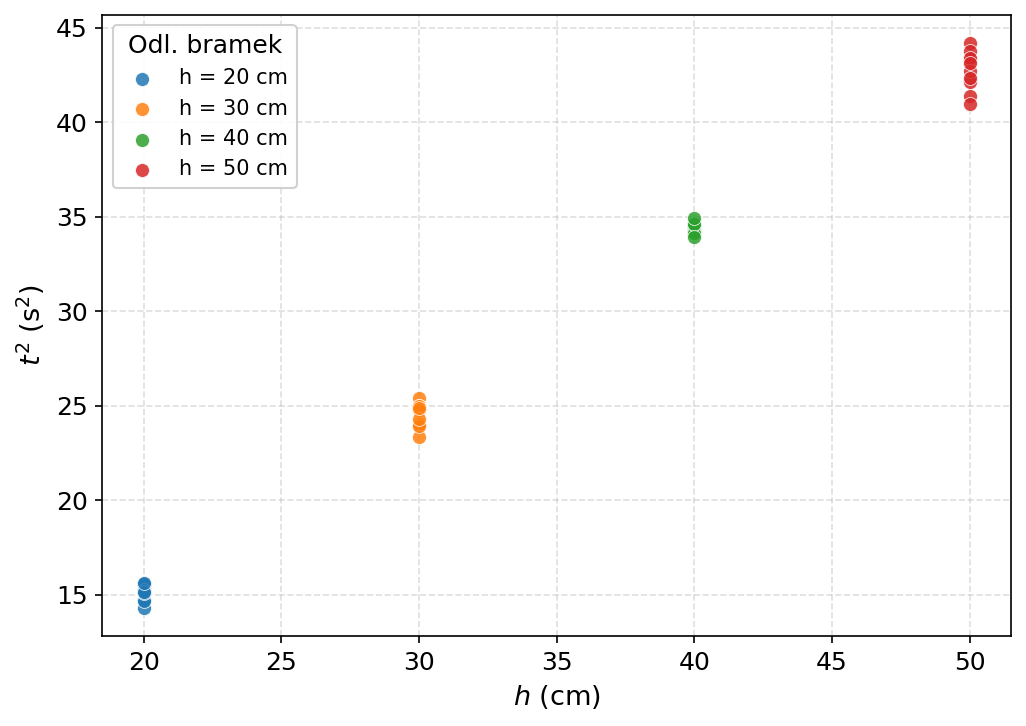

Zapisano: wykres1_surowe_h.pdf


In [4]:
# Wykres 1 — t² vs h
h_vals = sorted(df1['h'].unique())

fig, ax = plt.subplots(figsize=(7, 5))
for i, h_val in enumerate(h_vals):
    mask = df1['h'] == h_val
    ax.scatter(df1.loc[mask, 'h'], df1.loc[mask, 't2'],
               color=COLORS[i], s=45, alpha=0.85,
               edgecolors='white', linewidths=0.4,
               label=f'h = {h_val} cm', zorder=3)

ax.set_xlabel('$h$ (cm)')
ax.set_ylabel('$t^2$ (s$^2$)')
ax.legend(title='Odl. bramek', framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)
fig.tight_layout()
fig.savefig('wykres1_surowe_h.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Zapisano: wykres1_surowe_h.pdf')

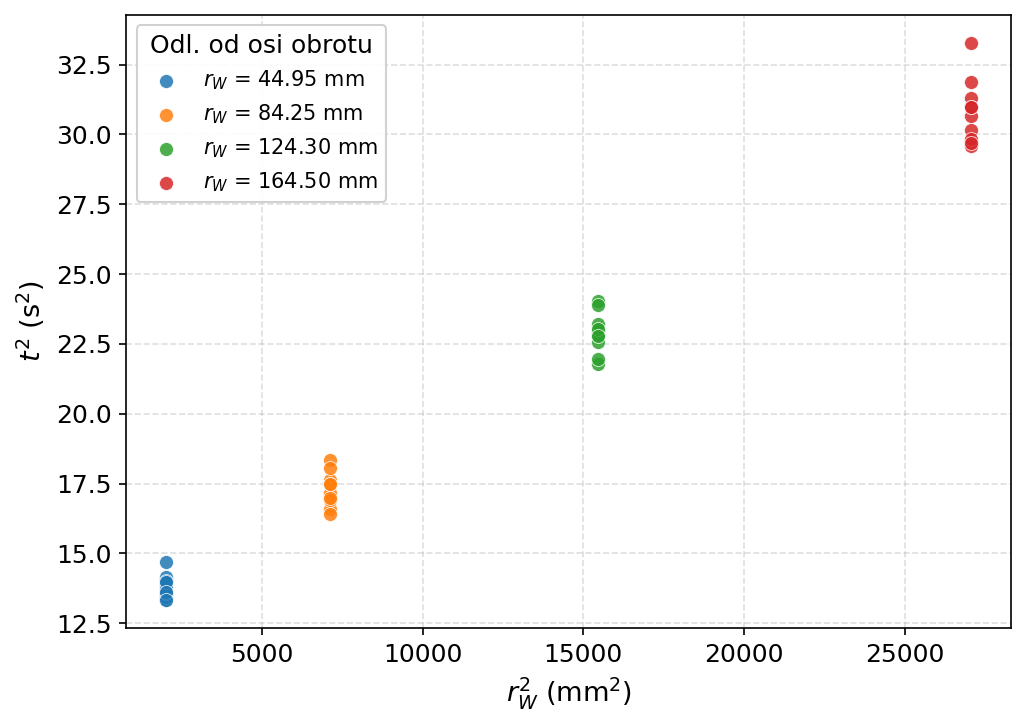

Zapisano: wykres2_surowe_dw2.pdf


In [5]:
# Wykres 2 — t² vs r²_W
dt_vals = sorted(df2['dt'].unique())

fig, ax = plt.subplots(figsize=(7, 5))
for i, dt_val in enumerate(dt_vals):
    mask = df2['dt'] == dt_val
    rw_val = (dt_val - H_W) / 2
    ax.scatter(df2.loc[mask, 'rw2'], df2.loc[mask, 't2'],
               color=COLORS[i], s=45, alpha=0.85,
               edgecolors='white', linewidths=0.4,
               label=f'$r_W$ = {rw_val:.2f} mm', zorder=3)

ax.set_xlabel('$r_W^2$ (mm$^2$)')
ax.set_ylabel('$t^2$ (s$^2$)')
ax.legend(title='Odl. od osi obrotu', framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)
fig.tight_layout()
fig.savefig('wykres2_surowe_dw2.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Zapisano: wykres2_surowe_dw2.pdf')

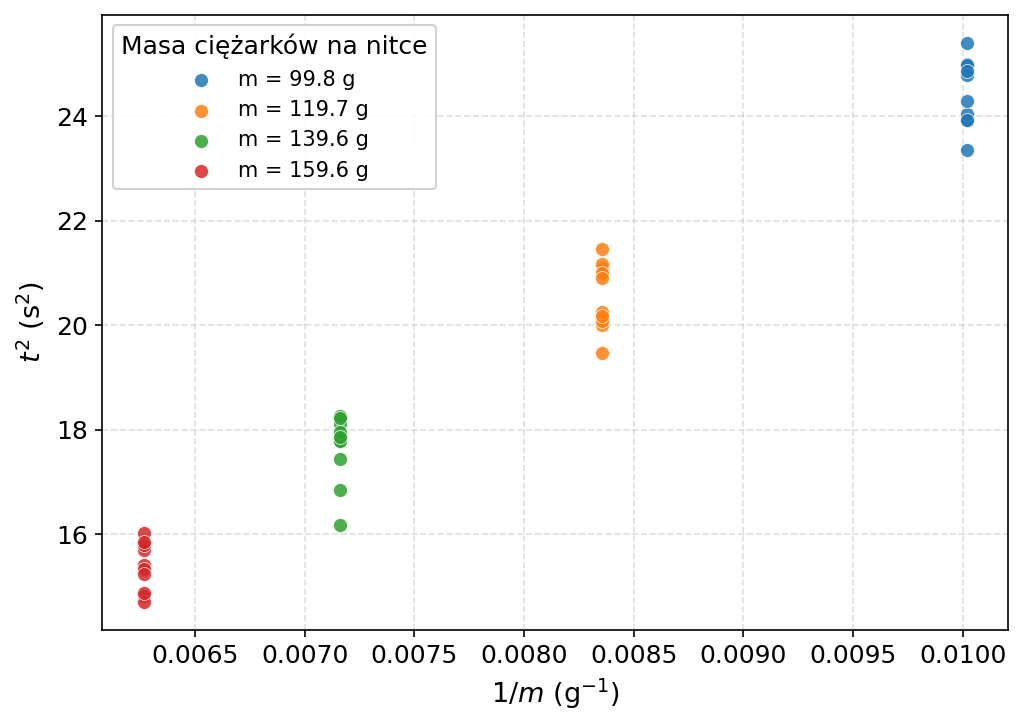

Zapisano: wykres3_surowe_m.pdf


In [6]:
# Wykres 3 — t² vs 1/m
m_vals = sorted(df3['m'].unique())

fig, ax = plt.subplots(figsize=(7, 5))
for i, m_val in enumerate(m_vals):
    mask = df3['m'] == m_val
    ax.scatter(df3.loc[mask, 'inv_m'], df3.loc[mask, 't2'],
               color=COLORS[i], s=45, alpha=0.85,
               edgecolors='white', linewidths=0.4,
               label=f'm = {m_val} g', zorder=3)

ax.set_xlabel('$1/m$ (g$^{-1}$)')
ax.set_ylabel('$t^2$ (s$^2$)')
ax.legend(title='Masa ciężarków na nitce', framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)
fig.tight_layout()
fig.savefig('wykres3_surowe_m.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Zapisano: wykres3_surowe_m.pdf')

## Statystyki — średnia i odchylenie standardowe $t^2$

In [7]:
# Oblicz średnie i odchylenia standardowe t² dla każdej serii
stats1 = df1.groupby('h')['t2'].agg(['mean', 'std']).reset_index()
stats1.columns = ['h_cm', 'mean_t2', 'std_t2']

stats2 = df2.groupby('dt').agg(
    mean_t2=('t2', 'mean'),
    std_t2=('t2', 'std'),
    rw_mm=('rw', 'first')
).reset_index()
stats2.columns = ['dt_mm', 'mean_t2', 'std_t2', 'rw_mm']
stats2['rw_cm'] = stats2['rw_mm'] / 10
stats2['rw2_cm2'] = stats2['rw_cm'] ** 2

stats3 = df3.groupby('m')['t2'].agg(['mean', 'std']).reset_index()
stats3.columns = ['m_g', 'mean_t2', 'std_t2']
stats3['inv_m'] = 1.0 / stats3['m_g']

print('=== Eksperyment 1: t² vs h ===')
tbl1 = stats1.copy()
tbl1.columns = ['h (cm)', '<t²> (s²)', 'σ(t²) (s²)']
display(tbl1.round(4))

print('\n=== Eksperyment 2: t² vs r²_W ===')
tbl2 = stats2[['dt_mm', 'rw_cm', 'rw2_cm2', 'mean_t2', 'std_t2']].copy()
tbl2.columns = ['d_t (mm)', 'r_W (cm)', 'r²_W (cm²)', '<t²> (s²)', 'σ(t²) (s²)']
display(tbl2.round(4))

print('\n=== Eksperyment 3: t² vs 1/m ===')
tbl3 = stats3[['m_g', 'inv_m', 'mean_t2', 'std_t2']].copy()
tbl3.columns = ['m (g)', '1/m (g⁻¹)', '<t²> (s²)', 'σ(t²) (s²)']
display(tbl3.round(5))

=== Eksperyment 1: t² vs h ===


,h (cm),<t²> (s²),σ(t²) (s²)
0,20,15.1069,0.4310
1,30,24.4568,0.6376
2,40,34.4340,0.2948
3,50,42.7171,1.0296



=== Eksperyment 2: t² vs r²_W ===


,d_t (mm),r_W (cm),r²_W (cm²),<t²> (s²),σ(t²) (s²)
0,99.9,4.495,20.2050,13.7931,0.4334
1,178.5,8.425,70.9806,17.3030,0.6138
2,258.6,12.430,154.5049,22.9023,0.7202
3,339.0,16.450,270.6025,30.8375,1.1449



=== Eksperyment 3: t² vs 1/m ===


,m (g),1/m (g⁻¹),<t²> (s²),σ(t²) (s²)
0,99.8,0.01002,24.45678,0.63764
1,119.7,0.00835,20.55808,0.64391
2,139.6,0.00716,17.64491,0.66362
3,159.6,0.00627,15.37114,0.46533


## Wykresy z regresją liniową

Regresja 1:  t² = a·h + b
  a = (0.956 ± 0.024) s²/cm
  b = (-3.98 ± 0.84) s²
  R² = 0.9990


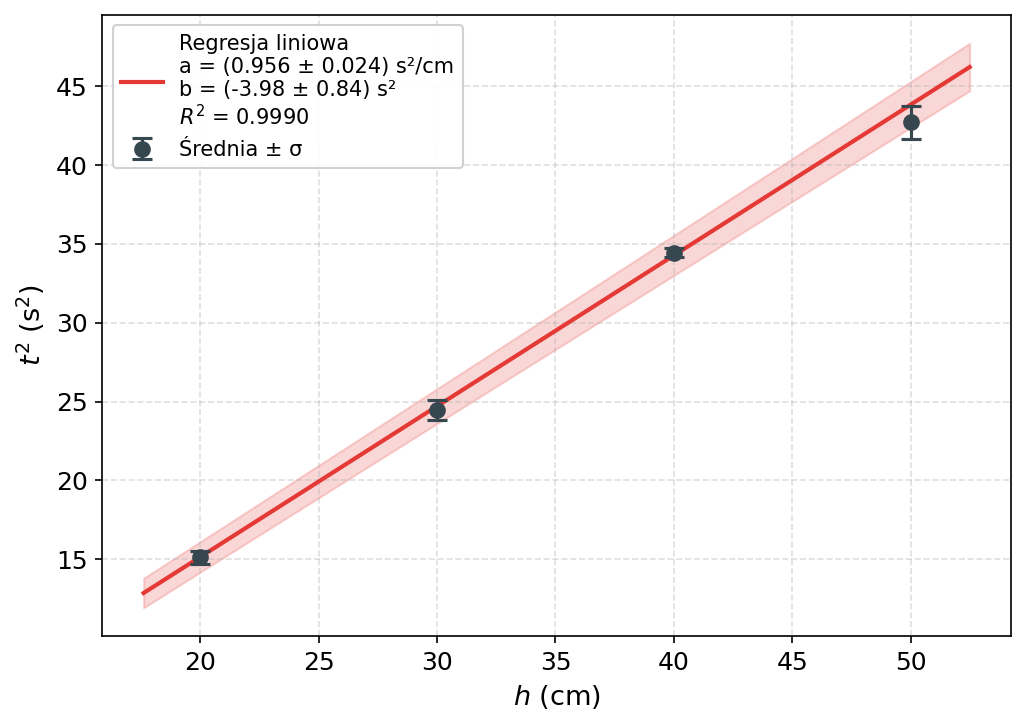

Zapisano: wykres4_regresja_h.pdf


In [8]:
# Wykres 4 — regresja liniowa: t² vs h
x1 = stats1['h_cm'].values
y1 = stats1['mean_t2'].values
yerr1 = stats1['std_t2'].values

a1, da1, b1, db1, r2_1 = fit_linear(x1, y1, yerr=yerr1)
av1, au1 = format_val_unc(a1, da1)
bv1, bu1 = format_val_unc(b1, db1)

print('Regresja 1:  t² = a·h + b')
print(f'  a = ({av1} ± {au1}) s²/cm')
print(f'  b = ({bv1} ± {bu1}) s²')
print(f'  R² = {r2_1:.4f}')

x_fit1 = np.linspace(x1.min() * 0.88, x1.max() * 1.05, 300)
y_fit1 = a1 * x_fit1 + b1
dy_fit1 = np.sqrt((da1 * x_fit1)**2 + db1**2)

label_fit1 = (f'Regresja liniowa\n'
              f'a = ({av1} \u00b1 {au1}) s\u00b2/cm\n'
              f'b = ({bv1} \u00b1 {bu1}) s\u00b2\n'
              f'$R^2$ = {r2_1:.4f}')

fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(x1, y1, yerr=yerr1, fmt='o', color='#37474F',
            capsize=5, elinewidth=1.5, capthick=1.5, markersize=7,
            label='Średnia ± σ', zorder=4)
ax.plot(x_fit1, y_fit1, color='#e53935', linewidth=2.0, label=label_fit1)
ax.fill_between(x_fit1, y_fit1 - dy_fit1, y_fit1 + dy_fit1, color='#e53935', alpha=0.2)
ax.set_xlabel('$h$ (cm)')
ax.set_ylabel('$t^2$ (s$^2$)')
ax.legend(framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)
fig.tight_layout()
fig.savefig('wykres4_regresja_h.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Zapisano: wykres4_regresja_h.pdf')

Regresja 2:  t² = a·r²_W + b
  a = (0.0680 ± 0.0042) s²/cm²
  b = (12.43 ± 0.44) s²
  R² = 1.0000


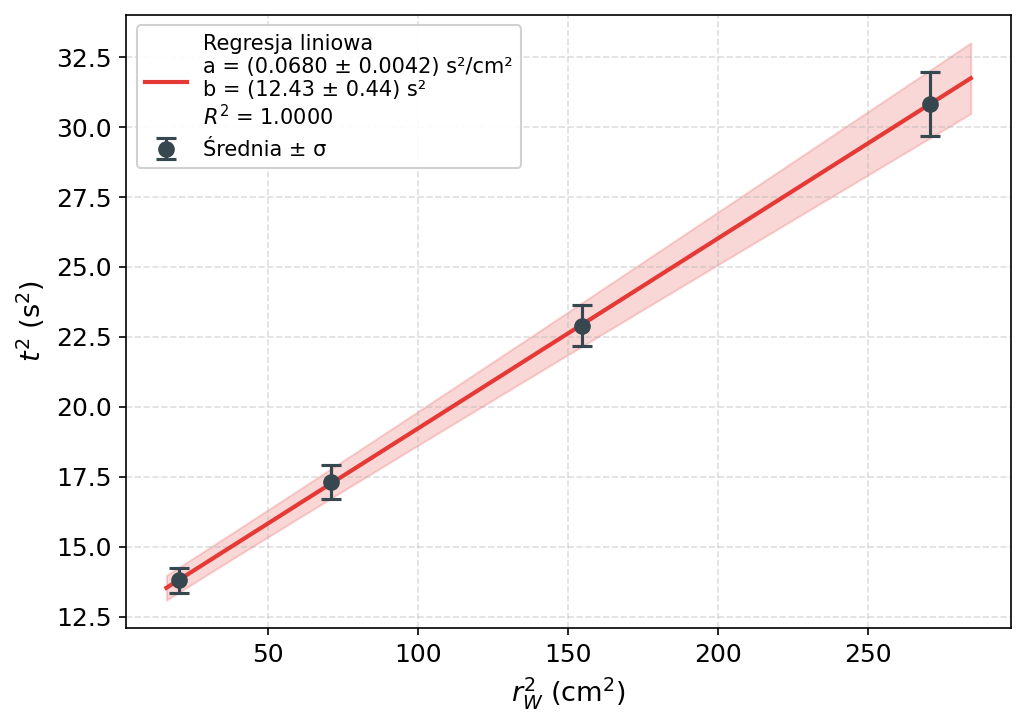

Zapisano: wykres5_regresja_dw2.pdf


In [9]:
# Wykres 5 — regresja liniowa: t² vs r²_W
x2 = stats2['rw2_cm2'].values
y2 = stats2['mean_t2'].values
yerr2 = stats2['std_t2'].values

a2, da2, b2, db2, r2_2 = fit_linear(x2, y2, yerr=yerr2)
av2, au2 = format_val_unc(a2, da2)
bv2, bu2 = format_val_unc(b2, db2)

print('Regresja 2:  t² = a·r²_W + b')
print(f'  a = ({av2} ± {au2}) s²/cm²')
print(f'  b = ({bv2} ± {bu2}) s²')
print(f'  R² = {r2_2:.4f}')

x_fit2 = np.linspace(x2.min() * 0.80, x2.max() * 1.05, 300)
y_fit2 = a2 * x_fit2 + b2
dy_fit2 = np.sqrt((da2 * x_fit2)**2 + db2**2)

label_fit2 = (f'Regresja liniowa\n'
              f'a = ({av2} \u00b1 {au2}) s\u00b2/cm\u00b2\n'
              f'b = ({bv2} \u00b1 {bu2}) s\u00b2\n'
              f'$R^2$ = {r2_2:.4f}')

fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(x2, y2, yerr=yerr2, fmt='o', color='#37474F',
            capsize=5, elinewidth=1.5, capthick=1.5, markersize=7,
            label='Średnia ± σ', zorder=4)
ax.plot(x_fit2, y_fit2, color='#e53935', linewidth=2.0, label=label_fit2)
ax.fill_between(x_fit2, y_fit2 - dy_fit2, y_fit2 + dy_fit2, color='#e53935', alpha=0.2)
ax.set_xlabel('$r_W^2$ (cm$^2$)')
ax.set_ylabel('$t^2$ (s$^2$)')
ax.legend(framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)
fig.tight_layout()
fig.savefig('wykres5_regresja_dw2.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Zapisano: wykres5_regresja_dw2.pdf')

Regresja 3:  t² = a·(1/m) + b
  a = (2420 ± 200) s²·g
  b = (0.2 ± 1.6) s²
  R² = 0.9997


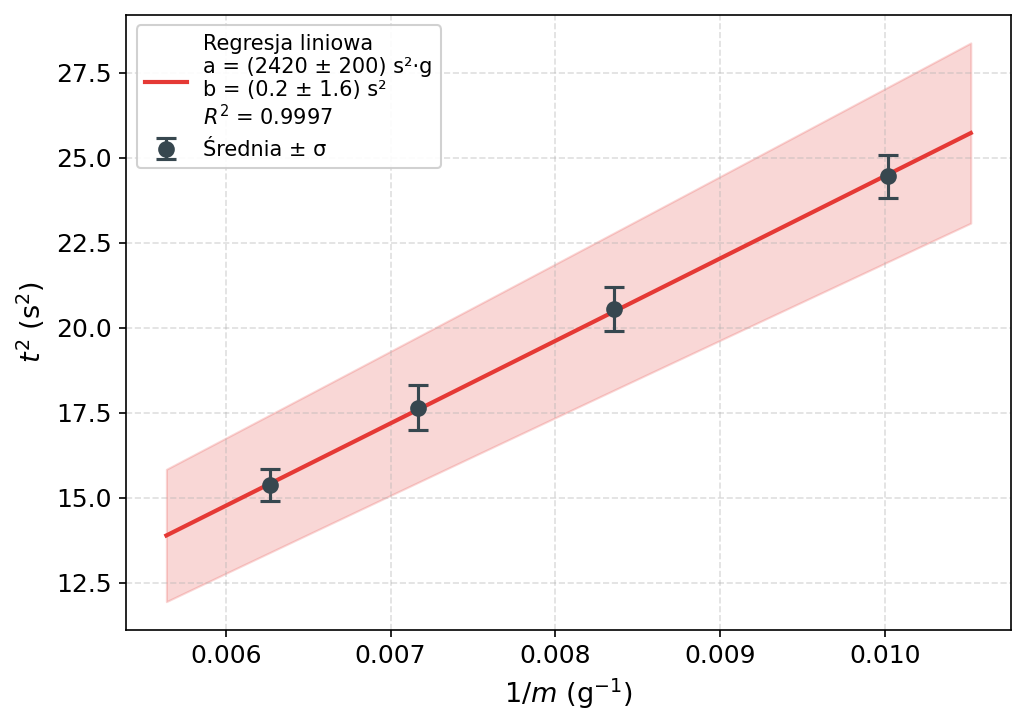

Zapisano: wykres6_regresja_m.pdf


In [10]:
# Wykres 6 — regresja liniowa: t² vs 1/m
x3 = stats3['inv_m'].values
y3 = stats3['mean_t2'].values
yerr3 = stats3['std_t2'].values

a3, da3, b3, db3, r2_3 = fit_linear(x3, y3, yerr=yerr3)
av3, au3 = format_val_unc(a3, da3)
bv3, bu3 = format_val_unc(b3, db3)

print('Regresja 3:  t² = a·(1/m) + b')
print(f'  a = ({av3} ± {au3}) s²·g')
print(f'  b = ({bv3} ± {bu3}) s²')
print(f'  R² = {r2_3:.4f}')

x_fit3 = np.linspace(x3.min() * 0.90, x3.max() * 1.05, 300)
y_fit3 = a3 * x_fit3 + b3
dy_fit3 = np.sqrt((da3 * x_fit3)**2 + db3**2)

label_fit3 = (f'Regresja liniowa\n'
              f'a = ({av3} \u00b1 {au3}) s\u00b2\u00b7g\n'
              f'b = ({bv3} \u00b1 {bu3}) s\u00b2\n'
              f'$R^2$ = {r2_3:.4f}')

fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(x3, y3, yerr=yerr3, fmt='o', color='#37474F',
            capsize=5, elinewidth=1.5, capthick=1.5, markersize=7,
            label='Średnia ± σ', zorder=4)
ax.plot(x_fit3, y_fit3, color='#e53935', linewidth=2.0, label=label_fit3)
ax.fill_between(x_fit3, y_fit3 - dy_fit3, y_fit3 + dy_fit3, color='#e53935', alpha=0.2)
ax.set_xlabel('$1/m$ (g$^{-1}$)')
ax.set_ylabel('$t^2$ (s$^2$)')
ax.legend(framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)
fig.tight_layout()
fig.savefig('wykres6_regresja_m.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Zapisano: wykres6_regresja_m.pdf')

## Wyznaczenie momentu bezwładności $J_X$ z regresji

### Eksperyment 1 — model $t^2$ vs $h$

Eksperyment prowadzony **bez ciężarków** ($J_W = 0$) przy stałej masie szalki $m$. Zależność ma postać:

$$t^2 = A_1 \cdot h + B_1$$

gdzie współczynnik kierunkowy:

$$A_1 = \frac{2(J_X + mr^2)}{mgr^2}$$

Stąd moment bezwładności:

$$\boxed{J_X = \frac{A_1 m g r^2}{2} - m r^2}$$

Propagacja niepewności (uwzględniając $u(A_1)$, $u(r)$, $u(m)$):

$$u(J_X) = \sqrt{\left(\frac{mgr^2}{2}\right)^2 u^2(A_1)+ \left(mr(A_1 g - 2)\right)^2 u^2(r) + \left(r^2\!\left(\frac{A_1 g}{2}-1\right)\right)^2 u^2(m)}$$

> **Uwaga:** masa szalki $m_1$ wczytana z pliku `1_hanging_mass.csv`.

In [11]:
# Stałe fizyczne
g = 9.81   # m/s²

# Konwersja a1: s²/cm  →  s²/m
a1_SI  = a1  * 100
da1_SI = da1 * 100

# Moment bezwładności z Eksp. 1
JX_1 = a1_SI * m1 * g * r**2 / 2  -  m1 * r**2

dJX1_dA = m1 * g * r**2 / 2
dJX1_dr = m1 * r * (a1_SI * g - 2)
dJX1_dm = r**2 * (a1_SI * g / 2 - 1)
uJX_1   = np.sqrt((dJX1_dA * da1_SI)**2 + (dJX1_dr * u_r)**2 + (dJX1_dm * u_m1)**2)

v1, u1 = format_val_unc(JX_1, uJX_1)
print('=== Eksperyment 1: t² vs h ===')
print(f'  A1   = ({format_val_unc(a1_SI, da1_SI)[0]} \u00b1 {format_val_unc(a1_SI, da1_SI)[1]}) s\u00b2/m')
print(f'  m1   = {m1*1e3:.1f} \u00b1 {u_m1*1e3:.1f} g')
print(f'  J_X  = ({v1} \u00b1 {u1}) kg\u00b7m\u00b2')
print(f'       = ({JX_1*1e3:.3f} \u00b1 {uJX_1*1e3:.3f}) \u00d7 10\u207b\u00b3 kg\u00b7m\u00b2')

=== Eksperyment 1: t² vs h ===
  A1   = (95.6 ± 2.4) s²/m
  m1   = 99.8 ± 0.1 g
  J_X  = (0.00472 ± 0.00013) kg·m²
       = (4.717 ± 0.127) × 10⁻³ kg·m²


### Eksperyment 3 — model $t^2$ vs $1/m$

Eksperyment prowadzony **bez ciężarków** ($J_W = 0$) przy stałej odległości bramek $h$. Zależność:

$$t^2 = A_3 \cdot \frac{1}{m} + B_3$$

gdzie:

$$A_3 = \frac{2h J_X}{g r^2}, \qquad B_3 = \frac{2h}{g}$$

Stąd moment bezwładności:

$$\boxed{J_X = \frac{A_3 g r^2}{2h}}$$

Propagacja niepewności (uwzględniając $u(A_3)$, $u(r)$, $u(h)$):

$$u(J_X) = \sqrt{\left(\frac{gr^2}{2h}\right)^2 u^2(A_3)+ \left(\frac{A_3 g r}{h}\right)^2 u^2(r) + \left(\frac{A_3 g r^2}{2h^2}\right)^2 u^2(h)}$$

> **Uwaga:** odległość bramek $h_3$ wczytana z pliku `3_gate_distance.csv`.

In [12]:
# Konwersja a3: s²·g  →  s²·kg
a3_SI  = a3  * 1e-3
da3_SI = da3 * 1e-3

# Moment bezwładności z Eksp. 3
JX_3 = a3_SI * g * r**2 / (2 * h3)

dJX3_dA = g * r**2 / (2 * h3)
dJX3_dr = a3_SI * g * r / h3
dJX3_dh = -a3_SI * g * r**2 / (2 * h3**2)
uJX_3   = np.sqrt((dJX3_dA * da3_SI)**2 + (dJX3_dr * u_r)**2 + (dJX3_dh * u_h3)**2)

v3, u3 = format_val_unc(JX_3, uJX_3)
print('=== Eksperyment 3: t² vs 1/m ===')
print(f'  A3   = ({format_val_unc(a3_SI, da3_SI)[0]} \u00b1 {format_val_unc(a3_SI, da3_SI)[1]}) s\u00b2\u00b7kg')
print(f'  h3   = {h3_cm:.1f} \u00b1 {u_h3cm:.1f} cm')
print(f'  J_X  = ({v3} \u00b1 {u3}) kg\u00b7m\u00b2')
print(f'       = ({JX_3*1e3:.3f} \u00b1 {uJX_3*1e3:.3f}) \u00d7 10\u207b\u00b3 kg\u00b7m\u00b2')

=== Eksperyment 3: t² vs 1/m ===
  A3   = (2.42 ± 0.20) s²·kg
  h3   = 30.0 ± 0.1 cm
  J_X  = (0.00400 ± 0.00034) kg·m²
       = (4.004 ± 0.337) × 10⁻³ kg·m²


### Eksperyment 2 — model $t^2$ vs $r_W^2$

Ciężarki są walcami ustawionymi z osią symetrii prostopadłą do osi obrotu. Kolumna $d_t$ w pliku CSV to **odległość między skrajnymi krawędziami** obu walców, dlatego odległość od osi obrotu do środka masy walca wynosi:

$$r_W = \frac{d_t - H_W}{2}$$

Moment bezwładności układu dwóch walców (łączna masa $M_W$, promień $R_W$, grubość $H_W$) — obrót wokół osi prostopadłej do osi symetrii przez środek masy walca, plus twierdzenie Steinera:

$$J_W = M_W\!\left(\frac{R_W^2}{4} + \frac{H_W^2}{12}\right) + M_W r_W^2 = J_{W,0} + M_W r_W^2$$

Regresja liniowa $t^2 = A_2 r_W^2 + B_2$ daje wyraz wolny:

$$B_2 = \frac{2h_2\!\left(J_X + J_{W,0} + m_2 r^2\right)}{m_2 g r^2}$$

Przy zmierzonej odległości bramek $h_2$ moment bezwładności wyznaczamy bezpośrednio z $B_2$:

$$\boxed{J_X = \frac{B_2\, m_2\, g\, r^2}{2h_2} - J_{W,0} - m_2 r^2}$$

Propagacja niepewności (z $u(B_2)$, $u(h_2)$, $u(r)$, $u(m_2)$, $u(M_W)$, $u(R_W)$, $u(H_W)$):

$$u(J_X) = \sqrt{\left(\frac{m_2 g r^2}{2h_2}\right)^2\!u^2(B_2)+\left(\frac{B_2 m_2 g r^2}{2h_2^2}\right)^2\!u^2(h_2)+\left(\frac{B_2 m_2 g r}{h_2}\right)^2\!u^2(r)+\left(\frac{B_2 g r^2}{2h_2}\right)^2\!u^2(m_2)+\left(\frac{R_W^2}{4}+\frac{H_W^2}{12}\right)^2\!u^2(M_W)+\left(\frac{M_W R_W}{2}\right)^2\!u^2(R_W)+\left(\frac{M_W H_W}{6}\right)^2\!u^2(H_W)}$$

In [13]:
# J_X z Eksp. 2 — model t² vs r²_W
# Regresja: t² = A₂·r²_W + B₂  (r_W w cm, t² w s²)
# J_X wyznaczony z wyrazu wolnego B₂ i zmierzonej odległości bramek h₂

# Konwersja a2: s²/cm²  →  s²/m² (informacyjnie)
a2_SI  = a2  * 1e4
da2_SI = da2 * 1e4

# Moment własny obu walców łącznie (oś przez CM, prostopadła do osi symetrii walca)
J_W0 = M_W * (R_W**2 / 4 + H_W_m**2 / 12)

# Moment bezwładności z Eksp. 2 (z wyrazu wolnego B₂)
JX_2 = b2 * m2 * g * r**2 / (2 * h2) - J_W0 - m2 * r**2

# Propagacja niepewności
dJX2_dB =  m2 * g * r**2 / (2 * h2)           # ∂J_X/∂B₂
dJX2_dh = -b2 * m2 * g * r**2 / (2 * h2**2)   # ∂J_X/∂h₂
dJX2_dr =  b2 * m2 * g * r / h2 - 2 * m2 * r  # ∂J_X/∂r
dJX2_dm =  b2 * g * r**2 / (2 * h2) - r**2     # ∂J_X/∂m₂
dJX2_dM = -(R_W**2 / 4 + H_W_m**2 / 12)        # ∂J_X/∂M_W
dJX2_dR = -M_W * R_W / 2                        # ∂J_X/∂R_W
dJX2_dH = -M_W * H_W_m / 6                      # ∂J_X/∂H_W

uJX_2 = np.sqrt(
    (dJX2_dB * db2)**2 +
    (dJX2_dh * u_h2)**2 +
    (dJX2_dr * u_r)**2 +
    (dJX2_dm * u_m2)**2 +
    (dJX2_dM * u_MW)**2 +
    (dJX2_dR * u_RW)**2 +
    (dJX2_dH * u_HW_m)**2
)

v2, u2 = format_val_unc(JX_2, uJX_2)
print('=== Eksperyment 2: t² vs r²_W ===')
print(f'  A2   = ({format_val_unc(a2_SI, da2_SI)[0]} ± {format_val_unc(a2_SI, da2_SI)[1]}) s²/m²')
print(f'  B2   = ({format_val_unc(b2, db2)[0]} ± {format_val_unc(b2, db2)[1]}) s²')
print(f'  h2   = {h2_cm} ± {u_h2cm} cm')
print(f'  J_W0 = {J_W0*1e3:.4f} × 10⁻³ kg·m²')
print(f'  J_X  = ({v2} ± {u2}) kg·m²')
print(f'       = ({JX_2*1e3:.3f} ± {uJX_2*1e3:.3f}) × 10⁻³ kg·m²')

=== Eksperyment 2: t² vs r²_W ===
  A2   = (680 ± 42) s²/m²
  B2   = (12.43 ± 0.44) s²
  h2   = 30.0 ± 0.1 cm
  J_W0 = 0.0173 × 10⁻³ kg·m²
  J_X  = (0.00406 ± 0.00015) kg·m²
       = (4.056 ± 0.150) × 10⁻³ kg·m²


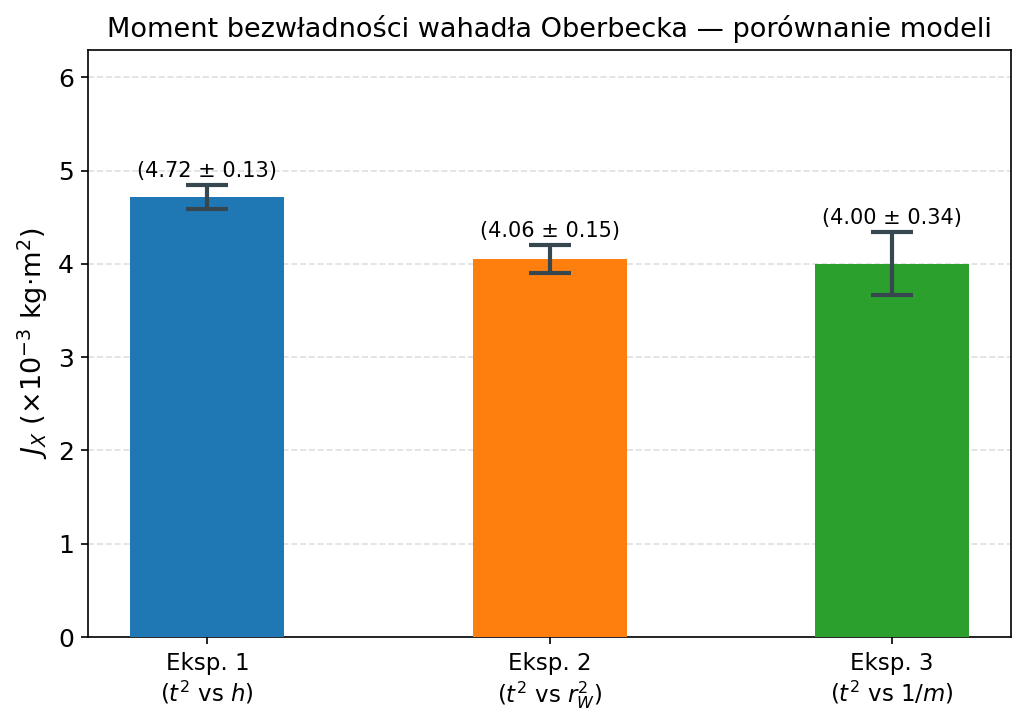

Zapisano: wykres7_jx_porownanie.pdf

=== Zestawienie wyników ===
  Eksp. 1: J_X = (4.72 ± 0.13) × 10⁻³ kg·m²
  Eksp. 2: J_X = (4.06 ± 0.15) × 10⁻³ kg·m²
  Eksp. 3: J_X = (4.00 ± 0.34) × 10⁻³ kg·m²


In [14]:
# Podsumowanie wyników i wykres słupkowy
labels  = ['Eksp. 1\n($t^2$ vs $h$)', 'Eksp. 2\n($t^2$ vs $r_W^2$)', 'Eksp. 3\n($t^2$ vs $1/m$)']
JX_vals = np.array([JX_1, JX_2, JX_3]) * 1e3   # w jednostkach 10⁻³ kg·m²
JX_errs = np.array([uJX_1, uJX_2, uJX_3]) * 1e3

bar_colors  = ['#1f77b4', '#ff7f0e', '#2ca02c']
ebar_kwargs = dict(elinewidth=2, capthick=2, capsize=10,
                   ecolor='#37474F', zorder=5)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, JX_vals, yerr=JX_errs,
              color=bar_colors, width=0.45,
              error_kw=ebar_kwargs, zorder=3)

# Etykiety wartości na słupkach
for bar, val, err in zip(bars, JX_vals, JX_errs):
    vstr, ustr = format_val_unc(val, err)
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + err + 0.04,
            f'({vstr} \u00b1 {ustr})',
            ha='center', va='bottom', fontsize=10)

ax.set_ylabel('$J_X$ ($\\times 10^{-3}$ kg\u00b7m$^2$)')
ax.set_title('Moment bezwładności wahadła Oberbecka — porównanie modeli')
ax.set_ylim(0, max(JX_vals + JX_errs) * 1.30)
ax.grid(True, linestyle='--', alpha=0.4, axis='y')
ax.tick_params(axis='x', labelsize=11)
fig.tight_layout()
fig.savefig('wykres7_jx_porownanie.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Zapisano: wykres7_jx_porownanie.pdf')

print()
print('=== Zestawienie wyników ===')
for lbl, jx, ujx in zip(['Eksp. 1', 'Eksp. 2', 'Eksp. 3'], [JX_1, JX_2, JX_3], [uJX_1, uJX_2, uJX_3]):
    vv, uu = format_val_unc(jx*1e3, ujx*1e3)
    print(f'  {lbl}: J_X = ({vv} \u00b1 {uu}) \u00d7 10\u207b\u00b3 kg\u00b7m\u00b2')